In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.columns = [c.strip() for c in df.columns]

if "Sleep Disorder" in df.columns:
    df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

print(df.head())
print(df.columns)

def map_sleep_level(score: float) -> str:
    """
   
    """
    if score <= 6:
        return "Poor"
    elif score <= 8:
        return "Neutral"
    # elif score <= 8:
    #     return "Good"
    else:
        return "Good"

print("Unique BMI values:", df["BMI Category"].unique())

# Map BMI categories to ordinal numeric values
bmi_map = {
    "Normal Weight": 1,
    "Normal": 1,
    "Overweight": 2,
    "Obese": 3,
}

df["BMI_num"] = df["BMI Category"].map(bmi_map)
df["BMI_num"] = df["BMI_num"].fillna(df["BMI_num"].median())

df["SleepLevel"] = df["Quality of Sleep"].apply(map_sleep_level)
df["SleepLevel"].value_counts(normalize=True)


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200           None  
1         125/80          75      

SleepLevel
Neutral    0.497326
Poor       0.312834
Good       0.189840
Name: proportion, dtype: float64

c:\Users\Lenovo\.conda\envs\deeplearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\Lenovo\.conda\envs\deeplearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

c:\Users\Lenovo\.conda\envs\deeplearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\Lenovo\.conda\envs\deeplearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by

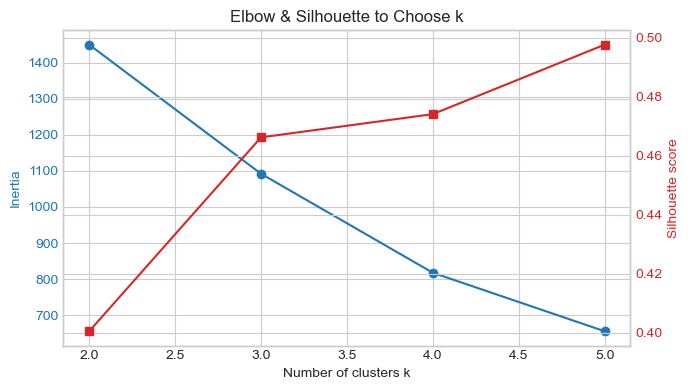

Chosen k (max silhouette): 5


In [104]:
# Lifestyle features to cluster on
cluster_features = [
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "BMI_num",
]

X = df[cluster_features].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose k using inertia + silhouette
k_range = range(2, 6)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan
    silhouettes.append(sil)

# Plot elbow + silhouette
fig, ax1 = plt.subplots(figsize=(7, 4))

color1 = "tab:blue"
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Inertia", color=color1)
ax1.plot(list(k_range), inertias, marker="o", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Silhouette score", color=color2)
ax2.plot(list(k_range), silhouettes, marker="s", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Elbow & Silhouette to Choose k")
fig.tight_layout()
plt.show()

# Pick best k by highest silhouette
valid_sil = [(k, s) for k, s in zip(k_range, silhouettes) if not np.isnan(s)]
best_k = max(valid_sil, key=lambda x: x[1])[0]
print("Chosen k (max silhouette):", best_k)


In [105]:
# Fit final KMeans with best_k
km = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = km.fit_predict(X_scaled)
df["Cluster"] = cluster_labels
df["Cluster"].value_counts()


c:\Users\Lenovo\.conda\envs\deeplearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\Lenovo\.conda\envs\deeplearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



Cluster
1    139
3     97
0     94
2     34
4     10
Name: count, dtype: int64

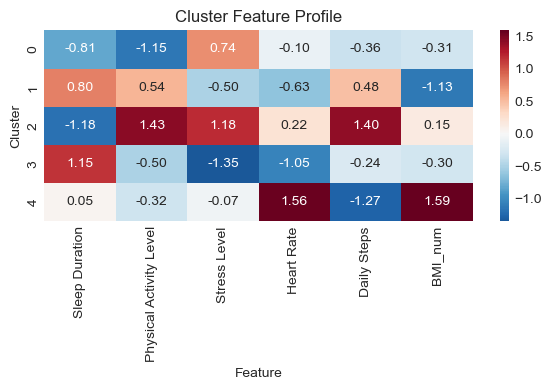

,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BMI_num
Cluster,,,,,,
0,-0.810379,-1.147397,0.738231,-0.104688,-0.361257,-0.305226
1,0.796404,0.535722,-0.495286,-0.630244,0.482639,-1.128632
2,-1.179292,1.429941,1.177454,0.224176,1.397220,0.149389
3,1.147248,-0.501253,-1.348378,-1.050597,-0.243910,-0.302694
4,0.046019,-0.317011,-0.072021,1.561353,-1.274691,1.587163


In [106]:
# Cluster feature profile heatmap
profile = df.groupby("Cluster")[cluster_features].mean()
# z-score per feature
profile_z = (profile - profile.mean()) / profile.std()

plt.figure(figsize=(6, 4))
sns.heatmap(
    profile_z,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)
plt.title("Cluster Feature Profile")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

profile_z


### **Cluster 0 – Low Sleep, Low Activity, High Stress**

Short sleep duration, very low physical activity, moderately high stress, and below-average daily steps. Represents an overall unhealthy, low-activity high-stress lifestyle.

### **Cluster 1 – High Sleep, Moderately Active, Low Stress (Healthy Cluster)**

Longest sleep duration, moderate physical activity, low stress, and healthy BMI. This is the healthiest lifestyle group.

### **Cluster 2 – Very Low Sleep, Very High Activity, Very High Stress**

Lowest sleep duration, highest activity level and steps, with very high stress. A high-intensity, high-stress lifestyle.

### **Cluster 3 – Long Sleep, Very Low Stress, Low Activity**

Long sleep duration and minimal stress, but low movement/steps. A low-activity lifestyle.

### **Cluster 4 – High BMI, High Heart Rate, Very Low Steps**

Highest BMI and heart rate, with the lowest daily steps and low activity. This is a high-BMI, high-heart-rate risk group with potential health concerns.



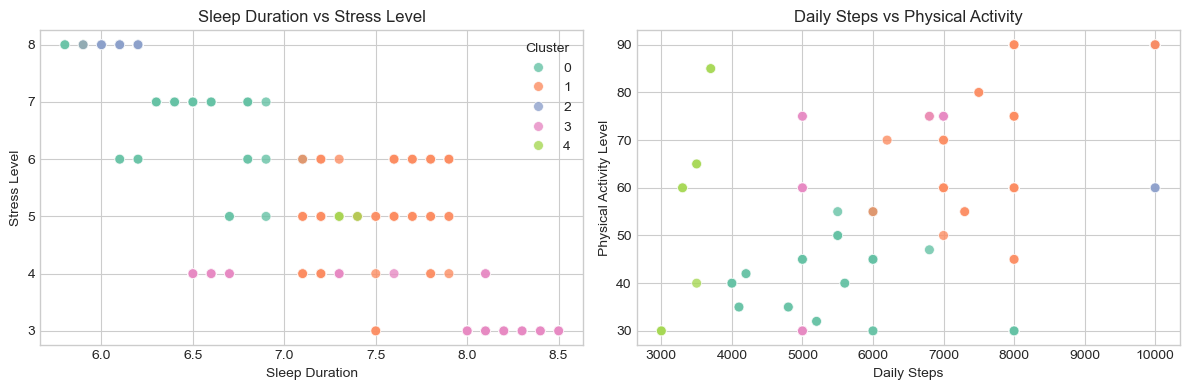

In [107]:
palette = sns.color_palette("Set2", n_colors=df["Cluster"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sleep Duration vs Stress Level
sns.scatterplot(
    x="Sleep Duration",
    y="Stress Level",
    hue="Cluster",
    palette=palette,
    data=df,
    s=50,
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title("Sleep Duration vs Stress Level")


# Daily Steps vs Physical Activity Level
sns.scatterplot(
    x="Daily Steps",
    y="Physical Activity Level",
    hue="Cluster",
    palette=palette,
    data=df,
    s=50,
    alpha=0.8,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Daily Steps vs Physical Activity")

plt.tight_layout()
plt.show()


In [108]:
ct_sleep = pd.crosstab(df["Cluster"], df["SleepLevel"], normalize="index")
ct_sleep

SleepLevel,Good,Neutral,Poor
Cluster,,,
0,0.000000,0.159574,0.840426
1,0.028777,0.971223,0.000000
2,0.000000,0.000000,1.000000
3,0.670103,0.329897,0.000000
4,0.200000,0.400000,0.400000


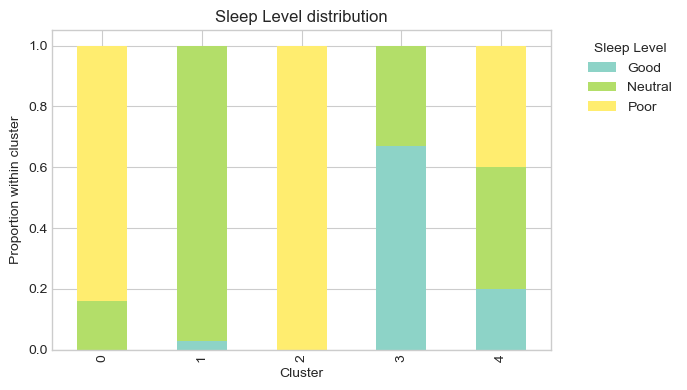

In [109]:
ct_sleep.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4),
    colormap="Set3"
)
plt.ylabel("Proportion within cluster")
plt.title("Sleep Level distribution")
plt.legend(title="Sleep Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


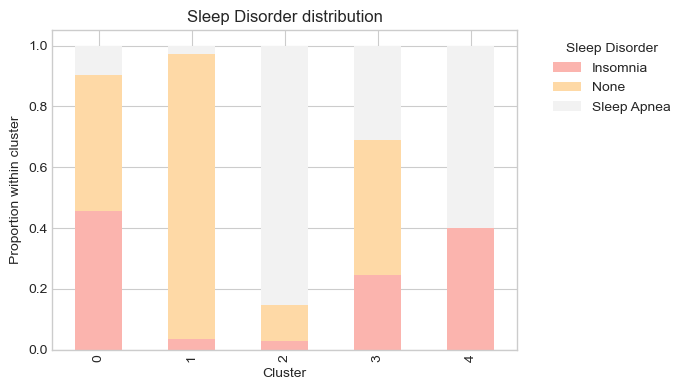

In [110]:
if "Sleep Disorder" in df.columns:
    ct_disorder = pd.crosstab(df["Cluster"], df["Sleep Disorder"], normalize="index")
    ct_disorder
if "Sleep Disorder" in df.columns:
    ct_disorder.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 4),
        colormap="Pastel1"
    )
    plt.ylabel("Proportion within cluster")
    plt.title("Sleep Disorder distribution")
    plt.legend(title="Sleep Disorder", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [111]:
# counts of each occupation in each cluster
occ_counts = pd.crosstab(df["Cluster"], df["Occupation"])
occ_counts


Occupation,Accountant,Doctor,Engineer,Lawyer,Manager,Nurse,Sales Representative,Salesperson,Scientist,Software Engineer,Teacher
Cluster,,,,,,,,,,,
0,6,31,3,3,1,5,0,32,4,1,8
1,31,34,21,42,0,3,0,0,0,2,6
2,0,2,0,0,0,32,0,0,0,0,0
3,0,0,39,0,0,33,0,0,0,0,25
4,0,4,0,2,0,0,2,0,0,1,1


In [112]:
# each cluster occupation proportion
occ_prop = pd.crosstab(df["Cluster"], df["Occupation"], normalize="index")
occ_prop


Occupation,Accountant,Doctor,Engineer,Lawyer,Manager,Nurse,Sales Representative,Salesperson,Scientist,Software Engineer,Teacher
Cluster,,,,,,,,,,,
0,0.063830,0.329787,0.031915,0.031915,0.010638,0.053191,0.0,0.340426,0.042553,0.010638,0.085106
1,0.223022,0.244604,0.151079,0.302158,0.000000,0.021583,0.0,0.000000,0.000000,0.014388,0.043165
2,0.000000,0.058824,0.000000,0.000000,0.000000,0.941176,0.0,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.402062,0.000000,0.000000,0.340206,0.0,0.000000,0.000000,0.000000,0.257732
4,0.000000,0.400000,0.000000,0.200000,0.000000,0.000000,0.2,0.000000,0.000000,0.100000,0.100000


In [113]:
# First k occupations
K = 10  # Can be adjusted
top_occ = df["Occupation"].value_counts().head(K).index.tolist()
print("Top occupations:", top_occ)

# keep only these occupations, others as 'Other'
df["Occ_simplified"] = df["Occupation"].where(df["Occupation"].isin(top_occ), "Other")

# each cluster occupation proportion
occ_prop_simple = pd.crosstab(df["Cluster"], df["Occ_simplified"], normalize="index")
occ_prop_simple


Top occupations: ['Nurse', 'Doctor', 'Engineer', 'Lawyer', 'Teacher', 'Accountant', 'Salesperson', 'Software Engineer', 'Scientist', 'Sales Representative']


Occ_simplified,Accountant,Doctor,Engineer,Lawyer,Nurse,Other,Sales Representative,Salesperson,Scientist,Software Engineer,Teacher
Cluster,,,,,,,,,,,
0,0.063830,0.329787,0.031915,0.031915,0.053191,0.010638,0.0,0.340426,0.042553,0.010638,0.085106
1,0.223022,0.244604,0.151079,0.302158,0.021583,0.000000,0.0,0.000000,0.000000,0.014388,0.043165
2,0.000000,0.058824,0.000000,0.000000,0.941176,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.402062,0.000000,0.340206,0.000000,0.0,0.000000,0.000000,0.000000,0.257732
4,0.000000,0.400000,0.000000,0.200000,0.000000,0.000000,0.2,0.000000,0.000000,0.100000,0.100000


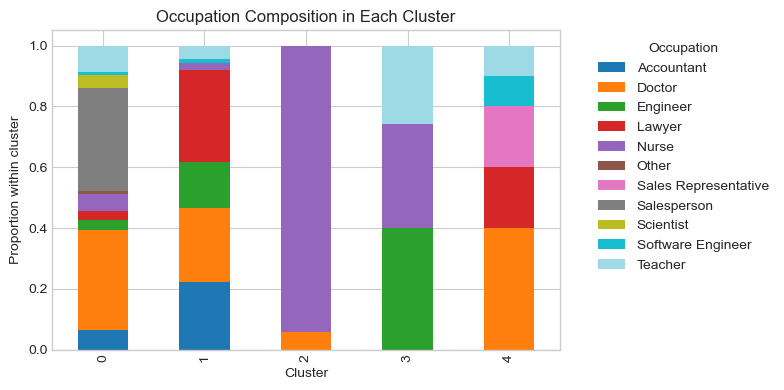

In [114]:
ax = occ_prop_simple.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
    colormap="tab20"
)
plt.ylabel("Proportion within cluster")
plt.xlabel("Cluster")
plt.title("Occupation Composition in Each Cluster")
plt.legend(title="Occupation", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


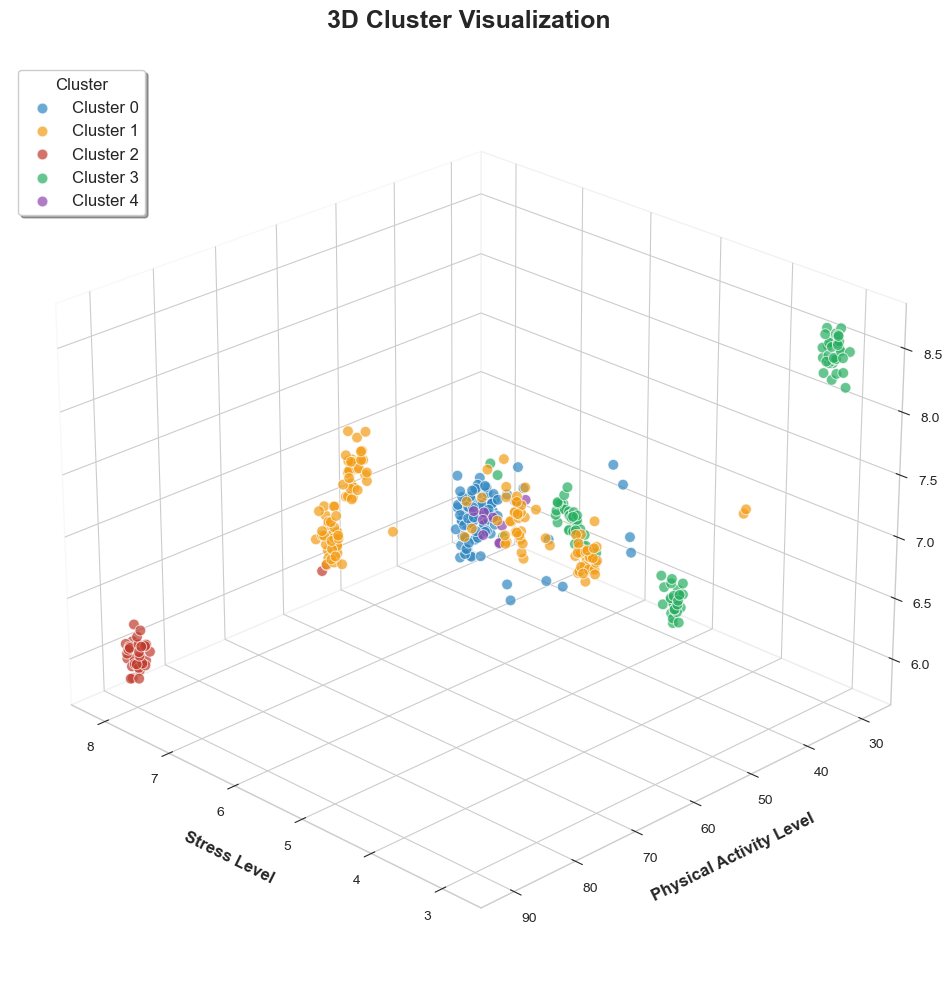

In [115]:
# 3D Cluster Visualization

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# 3 features
f1 = "Stress Level"
f2 = "Physical Activity Level"
f3 = "Sleep Duration"   

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = {
    0: "#2E86C1",   # Blue
    1: "#F39C12",   # Orange
    2: "#C0392B",   # Red
    3: "#27AE60",   # Green
    4: "#8E44AD",   # Purple
}

# Function to add jitter for separation
def add_jitter(arr, amount=0.15):
    return arr + np.random.uniform(-amount, amount, size=len(arr))

# Plot each cluster group
for cl in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cl].copy()
    
    # Add jitter
    x_j = add_jitter(subset[f1], 0.15)
    y_j = add_jitter(subset[f2], 0.8)
    z_j = add_jitter(subset[f3], 0.15)
    
    ax.scatter(
        x_j, y_j, z_j,
        c=colors[cl],
        label=f"Cluster {cl}",
        s=60,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.7
    )

ax.set_xlabel(f1, fontsize=12, labelpad=10, fontweight='bold')
ax.set_ylabel(f2, fontsize=12, labelpad=10, fontweight='bold')
ax.set_zlabel(f3, fontsize=12, labelpad=10, fontweight='bold')

ax.set_title(
    "3D Cluster Visualization",
    fontsize=18,
    fontweight='bold',
    pad=25
)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.4)

# Legend 
ax.legend(
    title="Cluster",
    fontsize=12,
    title_fontsize=12,
    loc='upper left',
    frameon=True,
    shadow=True
)

# View Angle
ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()
